## House price prediction using Machine Learning

Concept being used are
1. Python
2. XgBoost regresssion

In [1]:
# Lets import all the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [16]:
# As the default file is not available in sklearn so lets fetch it from web
import requests
import pandas as pd
from io import StringIO

# URL of the dataset
url = 'https://lib.stat.cmu.edu/datasets/boston'

# Fetch the dataset
response = requests.get(url)
data = response.text

# Split the data into lines
lines = data.strip().split('\n')

# Skip the header lines to get to the data
# The data starts after the 22nd line
data_lines = lines[22:]

# Initialize a list to hold the data
data_list = []

# Process the data: each data point spans two lines
for i in range(0, len(data_lines), 2):
    # First line: 12 features
    line1 = data_lines[i].strip()
    # Second line: 1 feature + target
    line2 = data_lines[i+1].strip()

    # Combine the two lines
    combined_line = line1 +' '+ line2
    # Split into individual numbers
    numbers = combined_line.split()
    # Convert strings to floats
    numbers = list(map(float, numbers))

    # Append to the data list
    data_list.append(numbers)

# Define the column names
columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
           'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'Price']

# Create a DataFrame
df = pd.DataFrame(data_list, columns=columns)

# Save to CSV
df.to_csv('boston_housing.csv', index=False)

print("Data has been saved to 'boston_housing.csv'")


Data has been saved to 'boston_housing.csv'


In [17]:
# Load the CSV file
df = pd.read_csv('boston_housing.csv')

# Display the first few rows
print(df.head())


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  Price  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  


In [18]:
# Checking the number of rows and columns in dataframe
df.shape

(506, 14)

In [19]:
#Checking for missign values
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [20]:
# Geting statistical summary of data
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Lets understand the correlation between our daatsets
There are 2 types of correlation
1. Positive correlation(directly proprotional)
2. Negative correlation(inversly proportional)

<Axes: >

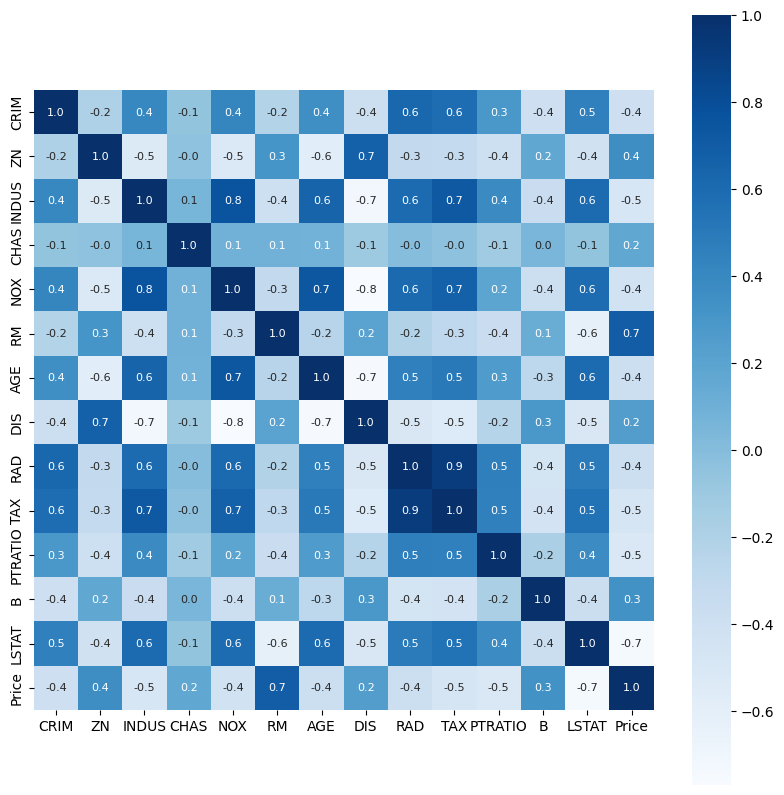

In [21]:
# Finding correlation between the features and visualizing them by constructing a heatmap
correlation = df.corr()
plt.figure(figsize =(10,10))
sns.heatmap(correlation, cbar = True, square = True, fmt = '.1f', annot = True, annot_kws = {'size':8}, cmap = 'Blues')

## Splittimg the data and Target

In [23]:
x = df.drop(['Price'], axis = 1) # axis = 1 indicates we are droping the column and axis = 0 for droping a row
y = df['Price']

In [24]:
print(x)
print(y)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...    ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786  1.0  273.0   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875  1.0  273.0   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675  1.0  273.0   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889  1.0  273.0   
505  0.04741   0.0  11.93   0.0  0.573  6.030  80.8  2.5050  1.0  273.0   

     PTRATIO       B  LSTAT  
0       15.3  396.90   4.98  
1       17.8  396.90   9.14  
2       1

## Splitting the data into train and test

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 40) # random state is used to reproduce the same split
print(x.shape, x_train.shape, x_test.shape)

(506, 13) (404, 13) (102, 13)


## XgBoost Model training

In [33]:
# Loading the model
model = XGBRegressor()

#training the model with train data
model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [34]:
# Lets predict on training data
training_data_prediction = model.predict(x_train)
print(training_data_prediction)


[28.051819  10.203798  32.19681   20.709862  29.42891   29.00026
 19.284767  10.895764  42.799835  49.996452  26.59021   23.789482
 22.182838  15.605244  19.003101  21.504288  49.99099   21.20231
 22.874224  30.041718  30.099886  14.116558  49.994583  14.5756855
 10.412106  29.594019  17.122513  26.350988  14.343281  24.787682
 23.501348  21.001272  30.098724  46.691833  27.497036  17.10814
 27.493826  20.383736  15.69384   50.002697  19.589884  22.296139
 25.00049   23.081543  13.406993  22.430944  18.389187  35.10232
 32.395195  14.489054  23.300318  15.001569  23.730198  20.914488
 26.593166  13.006789  19.894249  20.294132  18.082998  32.701263
 18.382307  22.304756  21.09524   31.494183  17.802988  21.761051
 18.501446  14.799257  29.802334  20.579615  22.002205  28.510824
 13.880391  10.189606  22.021248  49.999863  24.27442   24.594807
 19.47335   27.47328   13.811466  13.408889  15.430069  24.95935
 23.371681  20.59588   23.70068   19.505516  12.778504  26.98952
 23.909636  23.

In [35]:
# Lets evaluate wrt training data
#R squared error
score_1 = metrics.r2_score(y_train, training_data_prediction)

# Mean absolute error
score_2 = metrics.mean_absolute_error(y_train, training_data_prediction)

#printing those metrics
print("R squared error: ", score_1)
print("Mean absolute error: ", score_2)

R squared error:  0.9999960954676627
Mean absolute error:  0.012091574574461137


# Lets visualize the actual prices and predicted prices

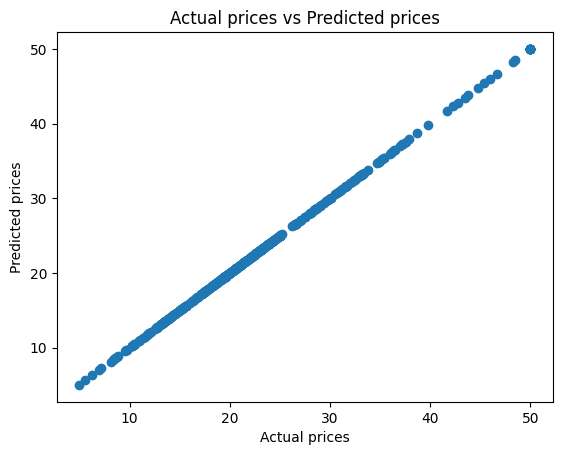

In [36]:
plt.scatter(y_train, training_data_prediction)
plt.xlabel("Actual prices")
plt.ylabel("Predicted prices")
plt.title("Actual prices vs Predicted prices")
plt.show()

In [29]:
# Error value for test data
test_data_prediction = model.predict(x_test)

#R square error calculation
score_1 = metrics.r2_score(y_test, test_data_prediction)

# Mean absolute error calculation
score_2 = metrics.mean_absolute_error(y_test, test_data_prediction)

# Prinitng those metrics
print("R squared error: ", score_1)
print("Mean absolute error: ", score_2)

R squared error:  0.9051721149855378
Mean absolute error:  2.0748727686264927


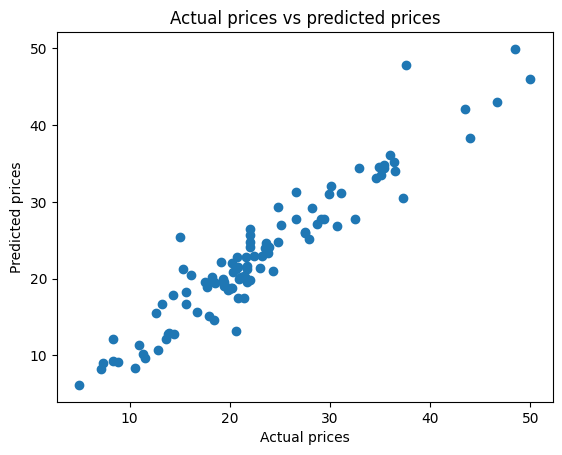

In [31]:
# Lets visualize for test data
plt.scatter(y_test, test_data_prediction)
plt.xlabel('Actual prices')
plt.ylabel('Predicted prices')
plt.title('Actual prices vs predicted prices')
plt.show()